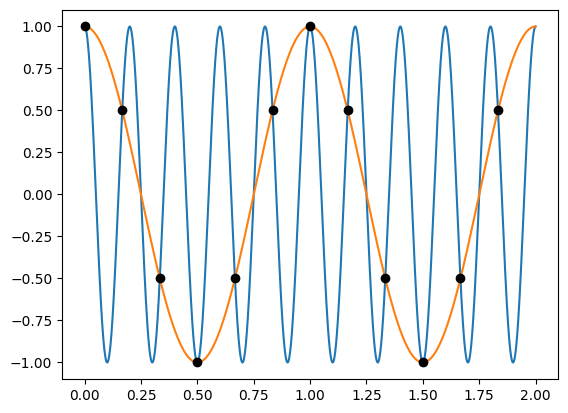

In [3]:
import numpy as np
import matplotlib.pyplot as plt

frequency =  5
sampledFrequency = 6
aliasFrequency = frequency - sampledFrequency
period = 1/sampledFrequency

pointsContinous = np.arange(0,2,0.0001)
initialSignal = np.cos(np.pi * 2 * frequency * pointsContinous)

aliasSignal = np.cos(np.pi * 2 * aliasFrequency * pointsContinous)

pointsDiscrete = np.arange(0,2,period)
pointsInitialSignal = np.cos(np.pi * 2 * frequency * pointsDiscrete)

plt.plot(pointsContinous,initialSignal)
plt.plot(pointsContinous,aliasSignal)
plt.plot(pointsDiscrete,pointsInitialSignal,"ko")

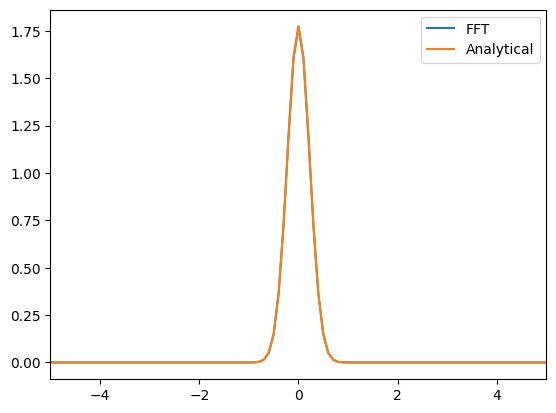

In [4]:
dt = 0.01
t = np.arange(-5,5,dt)
x = np.exp(-t**2)

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))*dt)
f = np.fft.fftshift(np.fft.fftfreq(len(t), dt))

X_analytical = np.sqrt(np.pi) * np.exp(-np.pi**2 * f**2)
plt.xlim(-5, 5)
plt.plot(f, np.real(X), label='FFT')
plt.plot(f, X_analytical, label='Analytical')
plt.legend()
plt.show()

/tmp/ipykernel_9965/696335182.py:8: RuntimeWarning: invalid value encountered in divide
  X_analytical = np.sin(np.pi * f) / (np.pi * f)


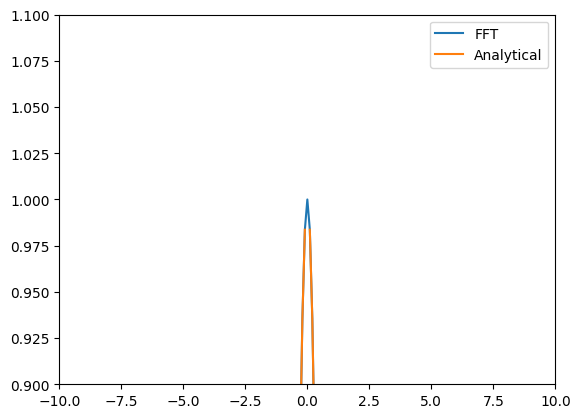

In [5]:
dt = 0.01
t = np.arange(-5,5,dt)
x = np.where(np.abs(t) <= 0.5, 1, 0)

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))*dt)
f = np.fft.fftshift(np.fft.fftfreq(len(t), dt))

X_analytical = np.sin(np.pi * f) / (np.pi * f)

plt.plot(f, np.real(X), label='FFT')
plt.plot(f, X_analytical, label='Analytical')
plt.xlim(-10, 10)
plt.ylim(0.9, 1.1)
plt.legend()
plt.show()

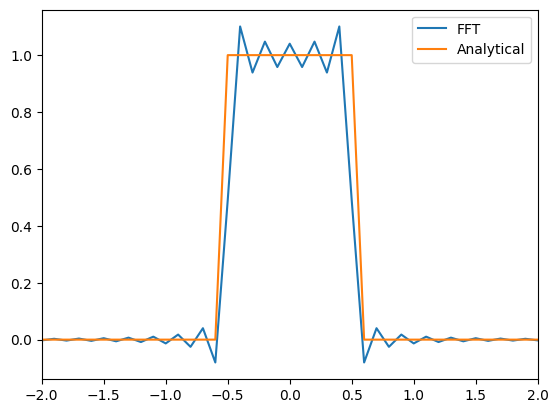

In [6]:
dt = 0.01
t = np.arange(-5,5,dt)
x = np.sin(np.pi*t)/(np.pi*t)

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))*dt)
f = np.fft.fftshift(np.fft.fftfreq(len(t),dt))

X_analytical = np.where(np.abs(f) <= 0.5, 1 ,0)
plt.xlim(-2, 2)
plt.plot(f, np.real(X), label='FFT')
plt.plot(f, X_analytical, label='Analytical')
plt.legend()
plt.show()

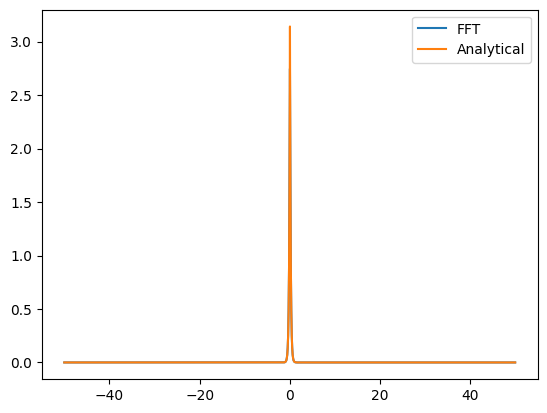

In [7]:
dt = 0.01
t = np.arange(-5,5,dt)
x = 1/(1+t ** 2)

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))*dt)
f = np.fft.fftshift(np.fft.fftfreq(len(t),dt))

X_analytical = np.pi*np.exp(-2 * np.pi * abs(f))

# plt.yscale('log')
plt.plot(f, np.real(X), label='FFT')
plt.plot(f, X_analytical, label='Analytical')
plt.legend()
plt.show()

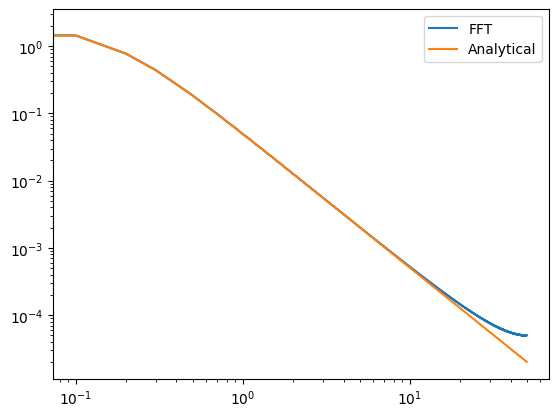

In [10]:
dt = 0.01
t = np.arange(-5,5,dt)
x = np.exp(-np.abs(t))

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))) *dt
f = np.fft.fftshift(np.fft.fftfreq(len(t),dt))

X_analytical = 2/(1 + 4 * np.pi**2 * (f**2))
plt.xscale('log')
plt.yscale('log')
plt.plot(f, np.real(X), label='FFT')
plt.plot(f, X_analytical, label='Analytical')
plt.legend()
plt.show()

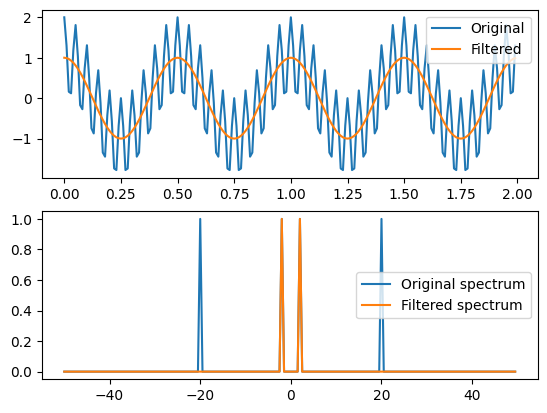

In [21]:
dt = 0.01
t = np.arange(0,2,0.01)
x = np.cos(np.pi * 2 * 2 * t) + np.cos (2 * np.pi * 20 * t)

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))*dt
f = np.fft.fftshift(np.fft.fftfreq(len(t),dt))

X_filtered = X.copy()
X_filtered[np.abs(f) > 10] = 0

x_filtered = np.real(np.fft.ifft(np.fft.ifftshift(X_filtered))) / dt

x_filtered = np.real(np.fft.ifft(np.fft.ifftshift(X_filtered))) / dt

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(t, x, label='Original')
ax1.plot(t, x_filtered, label='Filtered')
ax1.legend()

ax2.plot(f, np.abs(X), label='Original spectrum')
ax2.plot(f, np.abs(X_filtered), label='Filtered spectrum')
ax2.legend()
plt.show()